In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Load dataset
df = pd.read_csv("Dataset1.csv")

df = df.sort_values(["Train_No", "SN"])

# Convert time columns
df["Arrival_time"] = pd.to_datetime(
    df["Arrival_time"],
    format="%H:%M:%S"
)

df["Departure_Time"] = pd.to_datetime(
    df["Departure_Time"],
    format="%H:%M:%S"
)

# Prepare model dataset
model_data = df.groupby("Train_No").agg(
    Total_Distance=("Distance", "max"),
    Number_of_Stops=("Station_Name", "count"),
    Start_Time=("Departure_Time", "first"),
    End_Time=("Arrival_time", "last")
).reset_index()

# Handle overnight journeys
model_data.loc[
    model_data["End_Time"] < model_data["Start_Time"],
    "End_Time"
] += pd.Timedelta(days=1)

# Target column
model_data["Journey_Hours"] = (
    model_data["End_Time"] - model_data["Start_Time"]
).dt.total_seconds() / 3600

# Features and target
X = model_data[["Total_Distance", "Number_of_Stops"]]
y = model_data["Journey_Hours"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Comparison table
results = pd.DataFrame({
    "Actual_Journey_Hours": y_test.values,
    "Predicted_Journey_Hours": y_pred
})

results = results.round(2)

results.to_csv(
    "Actual_vs_Predicted_Journey_Time.csv",
    index=False
)

print("File saved successfully.")

print("Journey Time Prediction System")
display(results.head(10))

File saved successfully.
Journey Time Prediction System


,Actual_Journey_Hours,Predicted_Journey_Hours
0,11.50,6.15
1,3.00,4.37
2,0.92,3.26
3,3.17,2.16
4,1.88,4.11
5,0.63,1.58
6,7.50,4.87
7,0.98,1.54
8,11.75,11.79
9,19.75,8.77


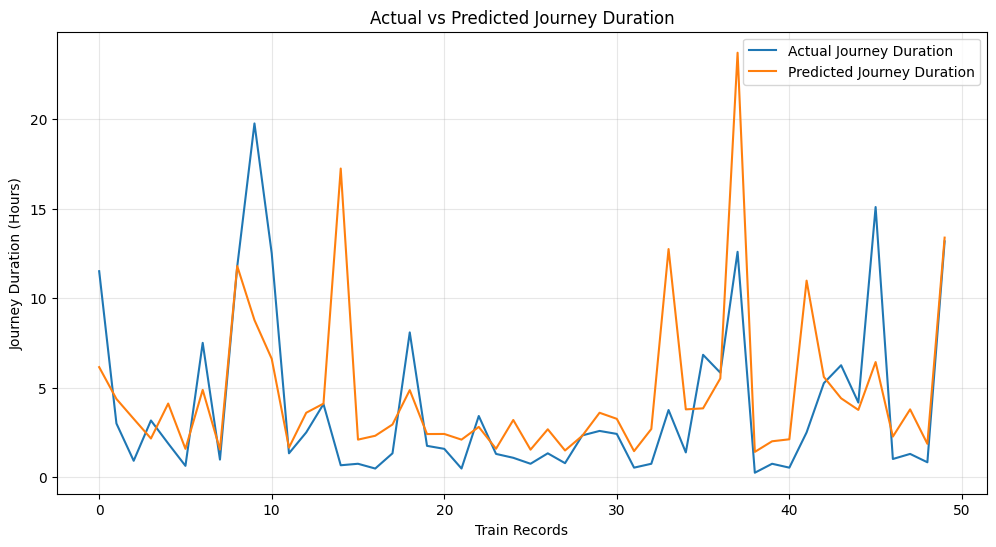

In [6]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison = comparison.head(50)

plt.figure(figsize=(12,6))

plt.plot(
    comparison["Actual"].values,
    label="Actual Journey Duration"
)

plt.plot(
    comparison["Predicted"].values,
    label="Predicted Journey Duration"
)

plt.xlabel("Train Records")
plt.ylabel("Journey Duration (Hours)")

plt.title("Actual vs Predicted Journey Duration")

plt.legend()

plt.grid(alpha=0.3)

plt.show()